### **Intensivity/Extensivity Analysis**

This notebook will build directly on the exploratory **02_exploration.ipynb** data analysis, looking deeper into the distinction between state-based intensivity of violence and non-state-based extensivity of violence.

This shall be tested across;
- timeframe (whether intensive/extensive dynamic is consistent or shifting between 2018-2024).
- space (whether dynamic is truly continental or concentrated in specific states).
- manner (which event types are responsible for state intensivity).

The analysis will also include robustness checks on the top 1% of fatal events to confirm trends.

Import libraries & Drive.

In [ ]:
#Import libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Import SciPy for statistical functions and Warnings to suppress warning messages.
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import Drive & files.
from google.colab import drive
drive.mount('/content/drive')
import gdown
drive_file_id = '1LhYVy64volmFM7oS868R5AvmpZ4W0loO'
gdown.download(id=drive_file_id, output='df_filtered.pkl', quiet=False)
df_filtered = pd.read_pickle('df_filtered.pkl')

Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=1LhYVy64volmFM7oS868R5AvmpZ4W0loO
To: /content/df_filtered.pkl
100%|██████████| 29.4M/29.4M [00:01<00:00, 20.4MB/s]


Define top 1% threshold for checks, use robust dataframe to allow later analysis to run with and without the top 1% included for statistical confirmation.

In [ ]:
# Prep data with actor tags and 1% threshold.
df_filtered['year_month'] = df_filtered['event_date'].dt.to_period('M')
state_events     = df_filtered[df_filtered['is_state_actor_event'] == 1]
non_state_events = df_filtered[df_filtered['is_non_state_actor_event'] == 1]
top1_threshold = df_filtered['fatalities'].quantile(0.99)
df_robust = df_filtered[df_filtered['fatalities'] <= top1_threshold]

# Print dataset with and without.
print(f"Full dataset: {len(df_filtered):,} rows")
print(f"Robust dataset (top 1% excluded, >{top1_threshold:.0f} fatalities): {len(df_robust):,} rows")
print(f"Events removed: {len(df_filtered) - len(df_robust):,}")

Full dataset: 195,807 rows
Robust dataset (top 1% excluded, >3 fatalities): 194,183 rows
Events removed: 1,624


Before testing time shift, need a single ratio to show gap between state and non-state lethality per year - mean fatalities/state-based event divided by mean fatalities/non-state-based event. Can then plot this over the year gap.

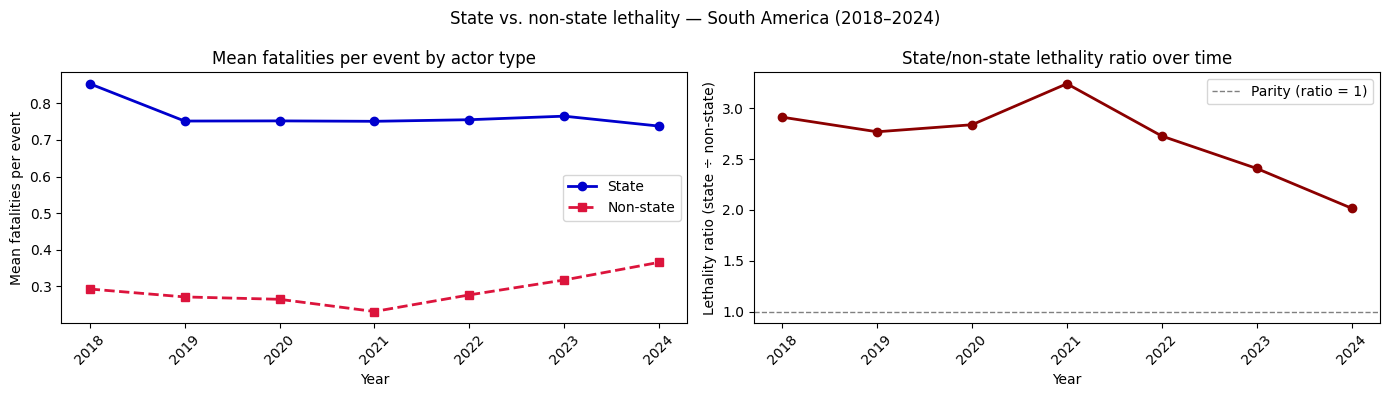

 year  lethality_ratio
 2018         2.913422
 2019         2.769708
 2020         2.839002
 2021         3.242884
 2022         2.727898
 2023         2.408725
 2024         2.017240


In [ ]:
# Calculate mean fatalities per event per year for each actor.
state_yearly_lethality = state_events.groupby('year')['fatalities'].mean()
nonstate_yearly_lethality = non_state_events.groupby('year')['fatalities'].mean()
lethality_ratio = (state_yearly_lethality / nonstate_yearly_lethality).reset_index()
lethality_ratio.columns = ['year', 'lethality_ratio']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot left lineplot with mean fatalities per event per year to compare actors.
axes[0].plot(state_yearly_lethality.index, state_yearly_lethality.values,
             marker='o', color='mediumblue', label='State', linewidth=2)
axes[0].plot(nonstate_yearly_lethality.index, nonstate_yearly_lethality.values,
             marker='s', color='crimson', label='Non-state', linewidth=2, linestyle='--')
axes[0].set_title('Mean fatalities per event by actor type')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean fatalities per event')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Plot right lineplot with lethality ratio.
axes[1].plot(lethality_ratio['year'], lethality_ratio['lethality_ratio'],
             marker='o', color='darkred', linewidth=2)
axes[1].axhline(y=1, color='grey', linestyle='--', linewidth=1, label='Parity (ratio = 1)')
axes[1].set_title('State/non-state lethality ratio over time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Lethality ratio (state ÷ non-state)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Format and save.
plt.suptitle('State vs. non-state lethality — South America (2018–2024)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_lethality_ratio.png', dpi=150)
plt.show()

# Print ratio values for report comparison.
print(lethality_ratio.to_string(index=False))

The ratio is of course above 1, as we know state actors are more lethal, but the ratio rising and falling demonstrates variation in how intensive state violence is compared to the non-state extensive. Peaks in 2021 and troughs in 2023/2024 need to be analysed further, and it is interesting noting their slight divergence from the raw fatality peaks in notebook 2 (2023); a year may be on-the-whole more violent, but we're interested in years where intensity and extensivity diverge the most.

But before proceeding, need to do robustness check on lethality ratio.

In [ ]:
results = []
for label, df in [('Full dataset', df_filtered), ('Excl. top 1%', df_robust)]:
    s = df[df['is_state_actor_event'] == 1]['fatalities']
    ns = df[df['is_non_state_actor_event'] == 1]['fatalities']
    results.append({
        'Dataset':              label,
        'State mean':           round(s.mean(), 3),
        'State median':         round(s.median(), 3),
        'Non-state mean':       round(ns.mean(), 3),
        'Non-state median':     round(ns.median(), 3),
        'Lethality ratio (mean)': round(s.mean() / ns.mean(), 2),
    })

robustness_df = pd.DataFrame(results)
print(robustness_df.to_string(index=False))

     Dataset  State mean  State median  Non-state mean  Non-state median  Lethality ratio (mean)
Full dataset       0.767           1.0           0.289               0.0                    2.66
Excl. top 1%       0.673           1.0           0.267               0.0                    2.52


Lethality ratio outputs are within 0.14 of one another, so ratio is not driven by anomalies for either actor; may proceed with analysis.

We can now ask what drives the fluctuations in the ratio - essentially, specifically where state violence becomes disproportionately more intense than non-state violence. To do this, compare the peak years to baseline years (i.e. 2018, 2020, 2022) in a bar chart to highlight which states drive spikes. A simultaneous chart on event breakdown within these spikes (by actor) will guide further understanding of spike causes.

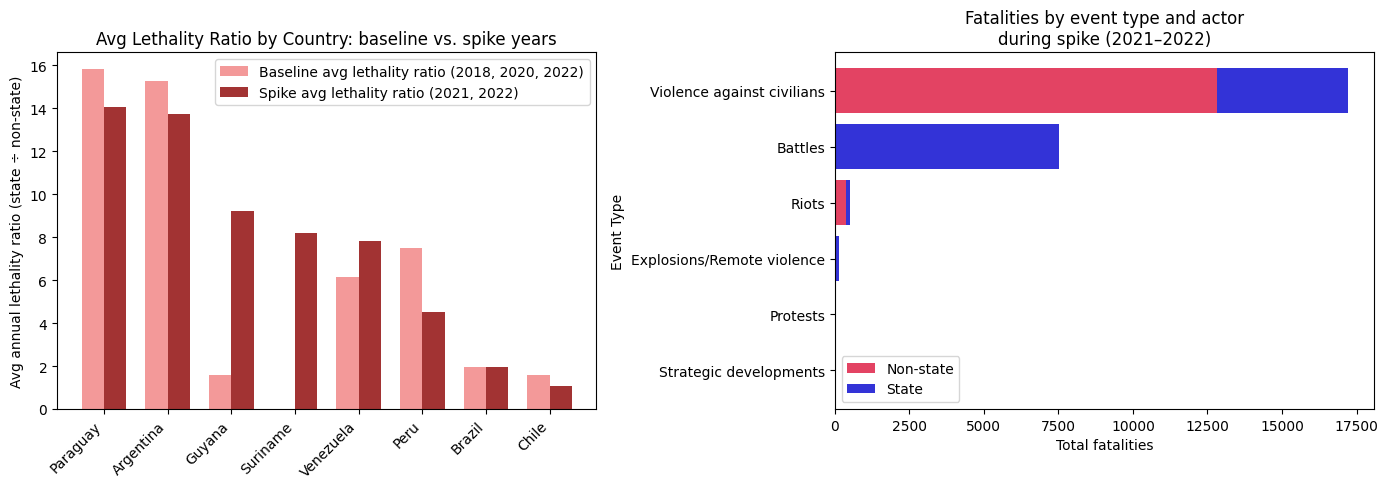

Top countries by average spike lethality ratio:
country
Paraguay     14.053782
Argentina    13.719664
Guyana        9.200000
Suriname      8.200000
Venezuela     7.829793
Peru          4.530229
Brazil        1.933457
Chile         1.075939
dtype: float64


In [ ]:
# Calculates yearly lethality ratio per country.
def calculate_yearly_country_lethality_ratios(df):
    state_events_df = df[df['is_state_actor_event'] == 1]
    non_state_events_df = df[df['is_non_state_actor_event'] == 1]

# Calculate mean fatalities per event per year per country.
    state_lethality_yearly_country = state_events_df.groupby(['year', 'country'])['fatalities'].mean()
    nonstate_lethality_yearly_country = non_state_events_df.groupby(['year', 'country'])['fatalities'].mean()

# Combine ratio into dataframe before division.
    combined_lethality = pd.DataFrame({
        'state_mean': state_lethality_yearly_country,
        'nonstate_mean': nonstate_lethality_yearly_country
    })

# Calculate ratio, handling potential division by zero resulting in inf by assigning NaN and dropping it.
    lethality_ratio_yearly_country = (combined_lethality['state_mean'] / combined_lethality['nonstate_mean'])
    lethality_ratio_yearly_country = lethality_ratio_yearly_country.replace([np.inf, -np.inf], np.nan).dropna()
    return lethality_ratio_yearly_country

# Filter spike and baseline years for analysis.
spike_years_df = df_filtered[df_filtered['year'].isin([2021,2022])]
baseline_years_df = df_filtered[df_filtered['year'].isin([2018, 2020, 2022])]

# Calculate yearly lethality ratios for each period.
spike_yearly_country_lethality_ratios = calculate_yearly_country_lethality_ratios(spike_years_df)
baseline_yearly_country_lethality_ratios = calculate_yearly_country_lethality_ratios(baseline_years_df)

# Average the yearly lethality ratios for each country.
spike_country_avg_lethality_ratio = spike_yearly_country_lethality_ratios.groupby('country').mean().sort_values(ascending=False)
baseline_country_avg_lethality_ratio = baseline_yearly_country_lethality_ratios.groupby('country').mean()

# Identify top states based on spike lethality ratio (using the averaged ratios), ensuring minimum amount.
num_countries = min(8, len(spike_country_avg_lethality_ratio))
countries = spike_country_avg_lethality_ratio.head(num_countries).index

# Prepare values by reindexing for order and handling missing values for plotting.
spike_vals = spike_country_avg_lethality_ratio.reindex(countries).fillna(0).values
baseline_vals = baseline_country_avg_lethality_ratio.reindex(countries).fillna(0).values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the left chart comparing average lethality ratio by country for baseline vs. spike years.
x = np.arange(len(countries))
width = 0.35
axes[0].bar(x - width/2, baseline_vals, width, label='Baseline avg lethality ratio (2018, 2020, 2022)',
            color='lightcoral', alpha=0.8)
axes[0].bar(x + width/2, spike_vals, width, label='Spike avg lethality ratio (2021, 2022)',
            color='darkred', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(countries, rotation=45, ha='right')
axes[0].set_title('Avg Lethality Ratio by Country: baseline vs. spike years')
axes[0].set_ylabel('Avg annual lethality ratio (state \u00f7 non-state)')
axes[0].legend()

# Plot the right chart showing event type breakdown within spike years, split by actors.
spike_state_fatalities = spike_years_df[spike_years_df['is_state_actor_event'] == 1].groupby('event_type')['fatalities'].sum()
spike_nonstate_fatalities = spike_years_df[spike_years_df['is_non_state_actor_event'] == 1].groupby('event_type')['fatalities'].sum()

# Combine state/non-state fatalities into dataframe, calculate total fatalities per event type.
combined_fatalities = pd.DataFrame({
    'state': spike_state_fatalities,
    'nonstate': spike_nonstate_fatalities
}).fillna(0)
combined_fatalities['total'] = combined_fatalities['state'] + combined_fatalities['nonstate']
combined_fatalities = combined_fatalities.sort_values('total', ascending=True)

# Plot stacked horizontal bar chart for fatalities by event type and actor during spike years.
ordered_event_types = combined_fatalities.index
state_vals_plot = combined_fatalities['state'].values
nonstate_vals_plot = combined_fatalities['nonstate'].values
axes[1].barh(ordered_event_types, nonstate_vals_plot, color='crimson', label='Non-state', alpha=0.8)
axes[1].barh(ordered_event_types, state_vals_plot, left=nonstate_vals_plot, color='mediumblue', label='State', alpha=0.8)
axes[1].set_title('Fatalities by event type and actor\nduring spike (2021\u20132022)')
axes[1].set_xlabel('Total fatalities')
axes[1].set_ylabel('Event Type')
axes[1].legend()

# Adjust layout, save, display.
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_spike_decomposition_lethality_ratio.png', dpi=150)
plt.show()

# Print the top countries by average spike lethality ratio for report.
print("Top countries by average spike lethality ratio:")
print(spike_country_avg_lethality_ratio.head(num_countries))

Paraguay and Argentina lead overall, highlighting generalised periods of high state violence in baseline and spike years alike, but the spike years are evidently underpinned by Guyana and Suriname's domestic lethality ratio spikes compared to violence levels in baseline periods.

The event subplot shows us that said fatalities stem from violence against civilians, approx. 3/4 non-state and 1/4 state, and battles, exclusively state-based. Protests are not as lethal as may have been thought, contributing no fatalities. This will guide later event-based analysis.

To wrap up spatial analysis, a heatmap comparing lethality ratio with overall average fatalities by country-actor will allow analysis of full state-by-state variation, and the scale of influence high-lethality nations like Paraguay and Argentina are having on the dynamic's pattern.

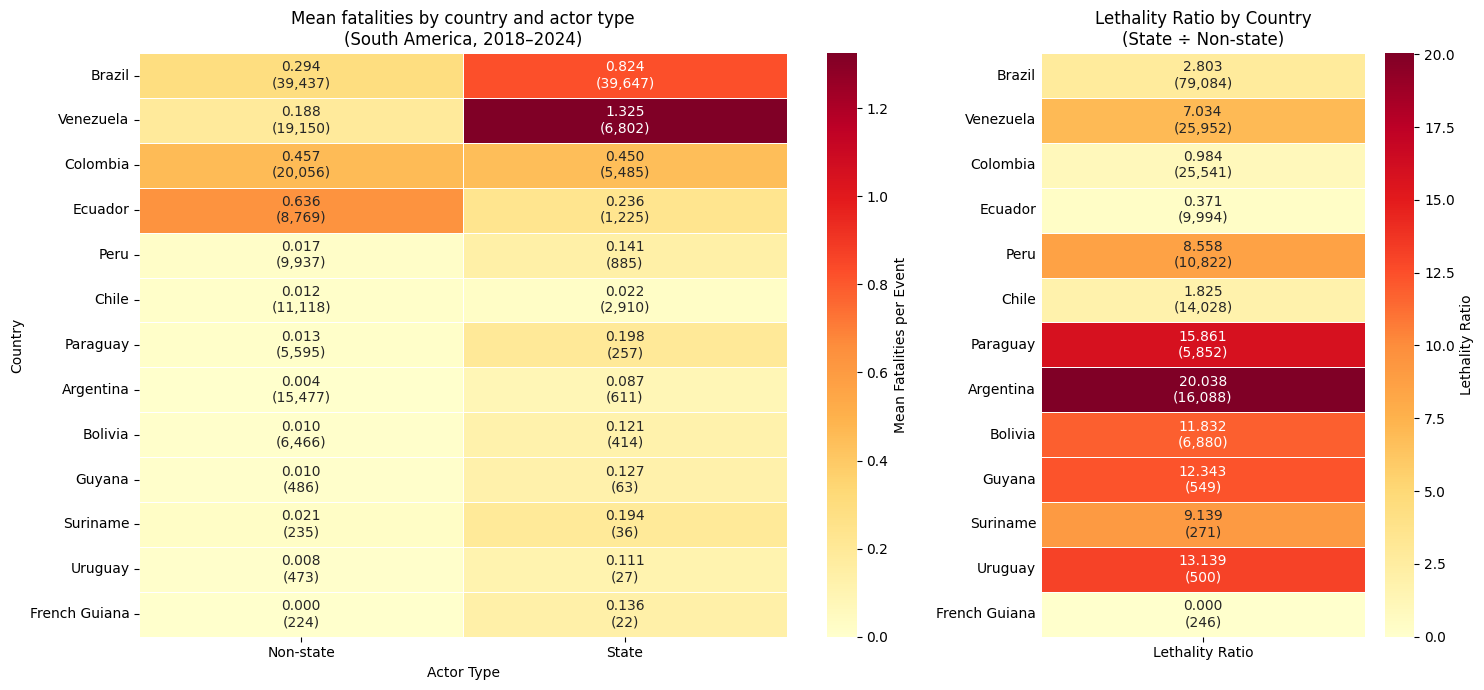

In [ ]:
# Mean fatalities per event by country and actor type (original first two columns)
country_lethality_mean_pivot = df_filtered.groupby(['country',
    df_filtered['is_state_actor_event'].map({1: 'State', 0: 'Non-state'})
])['fatalities'].mean().unstack(fill_value=0).round(3)
country_lethality_mean_pivot.columns.name = None # Remove the column name 'is_state_actor_event'

# Event counts for annotation context for 'State' and 'Non-state' columns
country_counts_pivot = df_filtered.groupby(['country',
    df_filtered['is_state_actor_event'].map({1: 'State', 0: 'Non-state'})
])['fatalities'].count().unstack(fill_value=0)
country_counts_pivot.columns.name = None # Remove the column name 'is_state_actor_event'

# Calculate lethality ratio for the second subplot
state_fatalities_mean = df_filtered[df_filtered['is_state_actor_event'] == 1].groupby('country')['fatalities'].mean()
non_state_fatalities_mean = df_filtered[df_filtered['is_state_actor_event'] == 0].groupby('country')['fatalities'].mean()

# Create a temporary DataFrame for ratio calculation to ensure consistent country index
ratio_calc_df = pd.DataFrame({
    'State_Mean': state_fatalities_mean,
    'Non_State_Mean': non_state_fatalities_mean
})
ratio_calc_df = ratio_calc_df.fillna(0) # Fill NaN for countries with no events for an actor type

lethality_ratio_series = (ratio_calc_df['State_Mean'] / ratio_calc_df['Non_State_Mean'])
lethality_ratio_series = lethality_ratio_series.replace([np.inf, -np.inf], np.nan).fillna(0).round(3)

# Total event counts for the 'Lethality Ratio' annotation (total events per country)
total_country_event_counts = df_filtered.groupby('country')['fatalities'].count()

# Prepare data for the first heatmap (Mean Fatalities per Actor Type)
heatmap_data_mean_fatalities = country_lethality_mean_pivot.copy()

# Prepare data for the second heatmap (Lethality Ratio)
heatmap_data_lethality_ratio = pd.DataFrame(lethality_ratio_series)
heatmap_data_lethality_ratio.columns = ['Lethality Ratio'] # Name the column for the heatmap

# Create annotation DataFrames
annotations_df_mean_fatalities = heatmap_data_mean_fatalities.copy().astype(str)
for country in annotations_df_mean_fatalities.index:
    mean_state = heatmap_data_mean_fatalities.loc[country, 'State']
    count_state = country_counts_pivot.loc[country, 'State']
    annotations_df_mean_fatalities.loc[country, 'State'] = f"{mean_state:.3f}\n({int(count_state):,})"

    mean_non_state = heatmap_data_mean_fatalities.loc[country, 'Non-state']
    count_non_state = country_counts_pivot.loc[country, 'Non-state']
    annotations_df_mean_fatalities.loc[country, 'Non-state'] = f"{mean_non_state:.3f}\n({int(count_non_state):,})"

annotations_df_lethality_ratio = heatmap_data_lethality_ratio.copy().astype(str)
for country in annotations_df_lethality_ratio.index:
    ratio_val = heatmap_data_lethality_ratio.loc[country, 'Lethality Ratio']
    total_country_events = total_country_event_counts.get(country, 0)
    annotations_df_lethality_ratio.loc[country, 'Lethality Ratio'] = f"{ratio_val:.3f}\n({int(total_country_events):,})"

# Sort by total fatalities for readability
country_order = df_filtered.groupby('country')['fatalities'].sum()\
                            .sort_values(ascending=False).index

heatmap_data_mean_fatalities = heatmap_data_mean_fatalities.reindex(country_order)
annotations_df_mean_fatalities = annotations_df_mean_fatalities.reindex(country_order)

heatmap_data_lethality_ratio = heatmap_data_lethality_ratio.reindex(country_order)
annotations_df_lethality_ratio = annotations_df_lethality_ratio.reindex(country_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [2, 1]})

# Plot mean fatalities heatmap.
sns.heatmap(heatmap_data_mean_fatalities, annot=annotations_df_mean_fatalities, fmt='', cmap='YlOrRd',
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Mean Fatalities per Event'})
ax1.set_title('Mean fatalities by country and actor type\n(South America, 2018–2024)')
ax1.set_xlabel('Actor Type')
ax1.set_ylabel('Country')

# Plot lethality ratio heatmap.
sns.heatmap(heatmap_data_lethality_ratio, annot=annotations_df_lethality_ratio, fmt='', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, cbar_kws={'label': 'Lethality Ratio'})
ax2.set_title('Lethality Ratio by Country\n(State \u00f7 Non-state)')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='y', length=0) # Remove y-ticks for the second subplot

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_country_lethality_heatmaps_split.png', dpi=150)
plt.show()


The left subplot reaffirms the generalised intensive/extensive dynamic, with nations like Peru having far more non-state events but higher state mean fatalities. Venezuela is a noteable outlier in terms of particular intensivity, whilst Ecuador is a complete exception with higher non-state fatality - Brazil is also worth deeper study in terms of a nigh-even number of state and non-state events. Of course Brazil, Venezuela and Colombia are driving lethality ratios by numbers, but the increases from non-state to state between Peru, Paraguay, Suriname etc. highlight the pattern's consistency.

The right subplot gives us a full picture of the lethality ratio, overtly visualising the differences we see on the left, essentially acting as a difference monitor to show how scale of events does not translate proportionately to state lethality. In fact, the lesser fatal events a nation has, the more likely they are to be state caused (with the exception of French Guiana).

We therefore ought to move from spatial-temporal to mechanical, and ask what specific events are occurring to produce said violence and lethality - basically moving from *who* and *when* to *what*. We can expand on the prior brief graph on sub-events in spike years, exploring events and sub-events in bar charts across years by state and non-state actors.

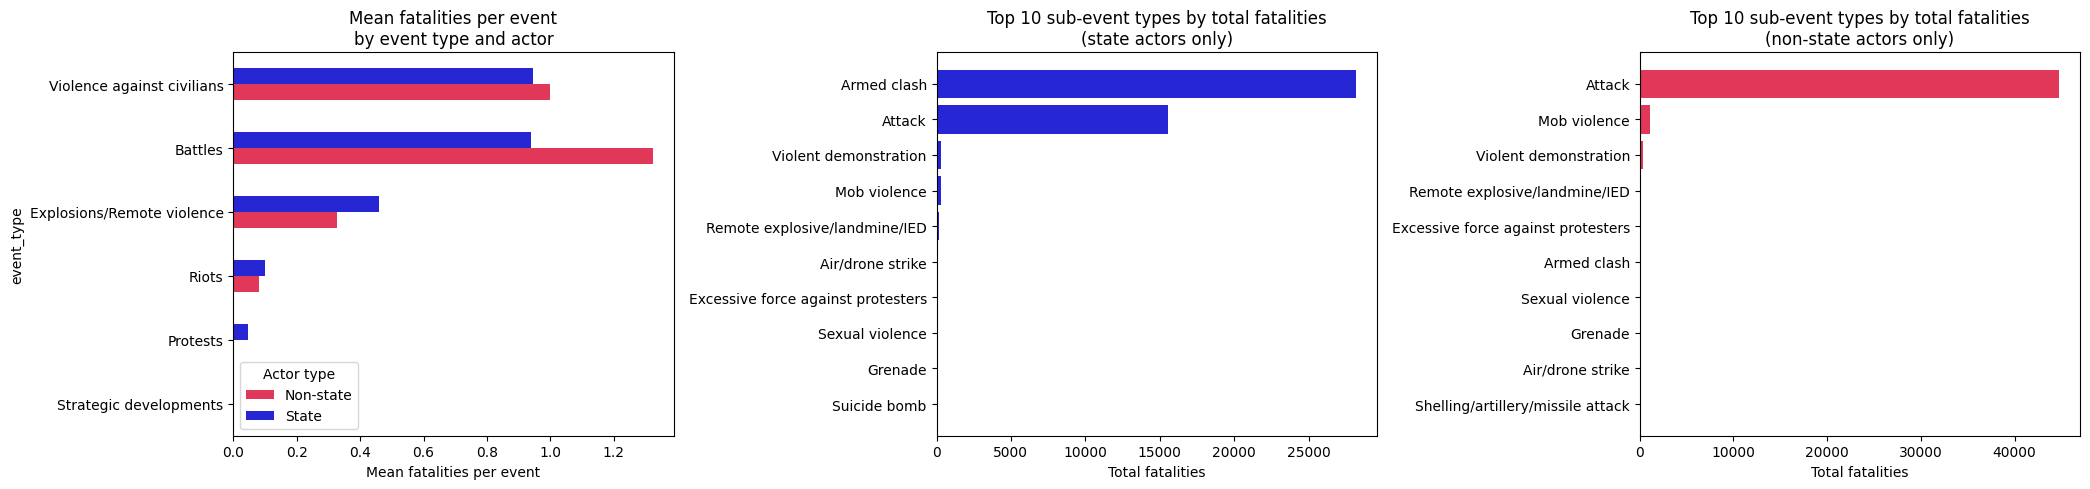


Full event type lethality breakdown:
                event_type actor_type  mean_fatalities  total_fatalities  event_count
                   Battles  Non-state            1.322                78           59
                   Battles      State            0.938             28170        30042
Explosions/Remote violence  Non-state            0.328               196          597
Explosions/Remote violence      State            0.459               390          850
                  Protests  Non-state            0.001                56        94057
                  Protests      State            0.046               105         2285
                     Riots  Non-state            0.081               893        10976
                     Riots      State            0.100               561         5601
    Strategic developments  Non-state            0.000                 0         2481
    Strategic developments      State            0.000                 0         3129
Violence against

In [ ]:
# Calculate event lethality metrics (mean, sum, count of fatalities) by event/actor type.
event_lethality = df_filtered.groupby([
    'event_type',
    df_filtered['is_state_actor_event'].map({1: 'State', 0: 'Non-state'})
])['fatalities'].agg(['mean', 'sum', 'count']).round(3)

# Rename columns.
event_lethality.columns = ['mean_fatalities', 'total_fatalities', 'event_count']
event_lethality = event_lethality.reset_index()
event_lethality.columns = ['event_type', 'actor_type',
                            'mean_fatalities', 'total_fatalities', 'event_count']

# Pivot mean fatalities for state and non-state actors for visualisation.
pivot_mean = event_lethality.pivot(index='event_type', columns='actor_type',
                                    values='mean_fatalities').fillna(0)
pivot_mean = pivot_mean.sort_values('State', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Plot left subplot with mean fatalities per event by type and actor.
pivot_mean.plot(kind='barh', ax=axes[0], color=['crimson', 'mediumblue'], alpha=0.85)
axes[0].set_title('Mean fatalities per event\nby event type and actor')
axes[0].set_xlabel('Mean fatalities per event')
axes[0].legend(title='Actor type')

# Plot centre subplot with top 10 sub-event types by total fatalities for state actors.
state_sub = (state_events.groupby('sub_event_type')['fatalities'].agg(['mean','sum'])
                         .sort_values('sum', ascending=True).tail(10))
axes[1].barh(state_sub.index, state_sub['sum'], color='mediumblue', alpha=0.85)
axes[1].set_title('Top 10 sub-event types by total fatalities\n(state actors only)')
axes[1].set_xlabel('Total fatalities')

# Plot right subplot with top 10 sub-event types by total fatalities for non-state actors.
non_state_sub = (non_state_events.groupby('sub_event_type')['fatalities'].agg(['mean','sum'])
                         .sort_values('sum', ascending=True).tail(10))
axes[2].barh(non_state_sub.index, non_state_sub['sum'], color='crimson', alpha=0.85)
axes[2].set_title('Top 10 sub-event types by total fatalities\n(non-state actors only)')
axes[2].set_xlabel('Total fatalities')

# Adjust layout, save, display.
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig_event_type_lethality.png', dpi=150)
plt.show()

# Print numerical breakdown of event type lethality for report.
print("\nFull event type lethality breakdown:")
print(event_lethality.sort_values(['event_type','actor_type']).to_string(index=False))

We can now move beyond generalisations of state violence and non-state violence to what is actually driving the dynamic. As expected, wider event type shows the consistency of the two actors in most lethal events (violence against civilians & battles), but is interesting to compare to the prior bar chart of spike years of state intensivity only, wherein violence against civilians was predominantly non-state-based whilst battles were exclusively state-based. We can therefore see that in years where the state is more lethal, this is due to battles, with the numerical output highlighting that the state has far, far more battles, with far more deaths, on the whole.

Dividing into subtypes produces a clear difference in the manner of lethality. State-based fatalities are approx. 2/3 from armed clashes and 1/3 from attacks, whilst non-state-based fatalities are almost all attacks. The state's wider use of more sophisticated arms may produce the intensive lethality from violence we see.

Visual-descriptive evidence all-in-all supports the intensive-extensive analysis, but given the non-normal distribution of the lesser numbered state-tagged events to non-state tagged, a test to disprove chance is required. The Mann-Whitney U Test is useful for formally affirming whether difference in per-event fatalities between state actor and non-state actor is indeed statistically significant.

In [ ]:
# Extract fatality values.
state_fat = state_events['fatalities'].values
nonstate_fat = non_state_events['fatalities'].values

# Perform Mann-Whitney U test on if state events are more lethal.
stat, p_value = stats.mannwhitneyu(state_fat, nonstate_fat, alternative='greater')

# Print results of Mann-Whitney U Test for full dataset.
print("Mann-Whitney U Test: State vs. Non-state per-event fatalities")
print(f"  H0: State and non-state fatality distributions are equal")
print(f"  H1: State actor events are more lethal (one-tailed)")
print(f"  U statistic: {stat:,.0f}")
print(f"  p-value: {p_value:.6f}")

# Interpret the p-value to determine if the null hypothesis should be rejected.
print(f"  Result: {'Reject H0 (significant at p<0.05)' if p_value < 0.05 else 'Fail to reject H0'}")

# Repeat test on robust dataset excluding top 1% fatal events.
stat_r, p_r = stats.mannwhitneyu(
    df_robust[df_robust['is_state_actor_event']==1]['fatalities'].values,
    df_robust[df_robust['is_non_state_actor_event']==1]['fatalities'].values,
    alternative='greater'
)

# Print results for robust dataset.
print(f"\n  Robust dataset (top 1% excluded) — p-value: {p_r:.6f}")

# Interpret p-value for the robust dataset.
print(f"  Result: {'Reject H0 (significant at p<0.05)' if p_r < 0.05 else 'Fail to reject H0'}")

Mann-Whitney U Test: State vs. Non-state per-event fatalities
  H0: State and non-state fatality distributions are equal
  H1: State actor events are more lethal (one-tailed)
  U statistic: 6,290,184,597
  p-value: 0.000000
  Result: Reject H0 (significant at p<0.05)

  Robust dataset (top 1% excluded) — p-value: 0.000000
  Result: Reject H0 (significant at p<0.05)


The test rejected hypothesis 0, as expected, but reaffirmed that state events are more lethal. A p-value less than 0.05 (probability of a false positive/chance) shows the lethality difference is statistically significant. Repeating with a robust dataset to double-check outliers outputted the same results, affirming that particularly lethal anomalies are not driving the dynamic nor the statistical significance of the dynamic.

Analysis across notebooks 1-3 set out to identify patterns in South American state and non-state violence, and has indeed found and affirmed state violence as intensive, and non-state violence as extensive. This dynamic held across spatial, temporal and mechanical analysis within this notebook, producing the following findings to be printed for the report.

In [ ]:
findings = {

    '1. Intensive/extensive dynamic confirmed':
        'State actors are more lethal, in 55.2% of events vs. 17.2% for non-state, '
        'state median fatalities per event (1.0) exceed non-state (0.0); '
        'distinction is not driven by outliers pulling up the mean.',

    '2. Lethality ratio consistently above parity':
        'State/non-state lethality ratio remains above 1.0 across every year '
        '2018–2024, confirming state is more intensively lethal in '
        'every observed year, not just on aggregate.',

    '3. Ratio variation: peak in 2021, trough in 2023–2024':
        'Lethality ratio peaks in 2021, falls toward 2023–2024, '
        'diverging from the raw fatality peak (2023). Years of high overall '
        'violence are not necessarily years of maximum state intensity.',

    '4. Robustness confirmed':
        'Lethality ratio on full dataset vs. top-1%-excluded dataset differs '
        'by 0.14; intensive/extensive gap is systemic pattern not driven by outliers.',

    '5. Spike driven by Guyana and Suriname (2021–2022)':
        'Paraguay and Argentina show elevated lethality ratios in both baseline '
        'and spike periods, but 2021–2022 intensification driven '
        'disproportionately by Guyana and Suriname, where state lethality '
        'rises sharply against low non-state baselines.',

    '6. Spike mechanism: battles (state) and violence against civilians (non-state)':
        'During 2021–2022 spike, battles exclusively state-driven '
        'while violence against civilians ~75% non-state. Protests '
        'contribute no fatalities.',

    '7. Spatial pattern holds, with two exceptions':
        'Intensive/extensive dynamic holds across most of continent. '
        'Ecuador is a clear exception (non-state fatalities exceed state).'
        'Brazil shows near-parity in state/non-state event counts.'
        'Venezuela exhibits highest state intensity of any country in dataset.',

    '8. Mechanism: armed clashes vs. attacks':
        'State fatalities are ~2/3 armed clashes and ~1/3 attacks; '
        'non-state fatalities are almost entirely attacks. '
        'State actors\' access to organised, combined-arms operations '
        'explains much of per-event intensity advantage.',

    '9. Statistical significance confirmed':
        'Mann-Whitney U test rejects H0 (p < 0.05) on both full and '
        'robust datasets. Lethality difference between state and '
        'non-state actors is statistically significant and not attributable '
        'to chance or extreme outliers.',
}

print("=" * 70)
print("SUMMARY OF FINDINGS — POLI3148 Assignment 1")
print("=" * 70)
for k, v in findings.items():
    print(f"\n{k}:\n  → {v}")

SUMMARY OF FINDINGS — POLI3148 Assignment 1

1. Intensive/extensive dynamic confirmed:
  → State actors are more lethal, in 55.2% of events vs. 17.2% for non-state, state median fatalities per event (1.0) exceed non-state (0.0); distinction is not driven by outliers pulling up the mean.

2. Lethality ratio consistently above parity:
  → State/non-state lethality ratio remains above 1.0 across every year 2018–2024, confirming state is more intensively lethal in every observed year, not just on aggregate.

3. Ratio variation: peak in 2021, trough in 2023–2024:
  → Lethality ratio peaks in 2021, falls toward 2023–2024, diverging from the raw fatality peak (2023). Years of high overall violence are not necessarily years of maximum state intensity.

4. Robustness confirmed:
  → Lethality ratio on full dataset vs. top-1%-excluded dataset differs by 0.14; intensive/extensive gap is systemic pattern not driven by outliers.

5. Spike driven by Guyana and Suriname (2021–2022):
  → Paraguay and A

To wrap up notebooks, we must be cogniscant of the limitiations of the data, including:
- The limited time frame of the dataset, only 6 years given the removal of half-finished 2025 (also misses 2025 figures, i.e. unrest in Colombia, Argentina or Ecuador).
- Labelling of actors by keywords; good for categorising many actor labels but may have miscategorised hybrid actors without keywords into 'Other', i.e. state-affiliated militias.
- ACLED acknowledges fatality reporting as a lower bound regarding remote/rural areas, where state or non-state lethality could be more likely depending on nation.
- Events involving both actors are included in both subsets; analytically appropriate for intenstive/extensive dynamic (both involved) but subset sizes cannot be exclusive counts.
- Equally, no way to measure which actor initiated a given event if both are tagged.
- Nature of ratio means smaller nations are more sensitive to more slight increases in events, so should be interpreted as such (namely Suriname & Guyana interpretation).

Ultimately, these notebooks aimed to move beyond aggregate fatality count (most predominant method of violence reporting) to instead characterise *how* different actors kill differently. The intensive/extensive framework developed offers a deeper analysis of violence in South America; the state is not necessarily more violent, it is more so more intense in its violence. Non-state actors may be more widely violent, generating more overall fatalities, but the comparative lethality of state actors per-event is a facet requiring far further discussion in regional conflict analysis.

The practical implications of these analyses are that resolving continental violence lies in multifaceted domestic and transnational policy response. Civilian protection frameworks are evidently needed to mitigate state-based lethality, particularly when using arms, whilst counter-organised-crime measures must continue to be bolstered to mitigate non-state lethality. Within this, regional variation is evident, and regional strategy requires national understanding to be effective.

Further analysis, ideally over a longer time-frame and with more specific actor categorisation, may bring in variables on state/regime style, i.e. rule of law scores or V-DEM indicies, to further deepen analysis of intensity and work towards conflict prevention.